In [1]:
import sys

sys.path.append("..")
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.evaluate import plot_predictions
from src.interpret import run_shap_analysis
from src.models import evaluate_models

df = pd.read_csv("../data/processed/delhi_featured.csv")
leaderboard = evaluate_models(df, target_col="Target_PM25_t1")

print("=== Cross-Validation Results ===")
display(leaderboard)

c:\Users\HP\Documents\P_jects\air_quality\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Cross-Validation Results ===


,Model,Mean RMSE,Mean MAE,Mean R2
0,Baseline (Ridge),42.411,28.797,0.679
1,XGBoost,43.552,28.404,0.658
2,LightGBM,44.380,29.657,0.625
3,CatBoost,44.444,29.297,0.635
4,Random Forest,44.633,27.670,0.635


<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_13004\4100904214.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("RMSE ($\mu g/m^3$)")


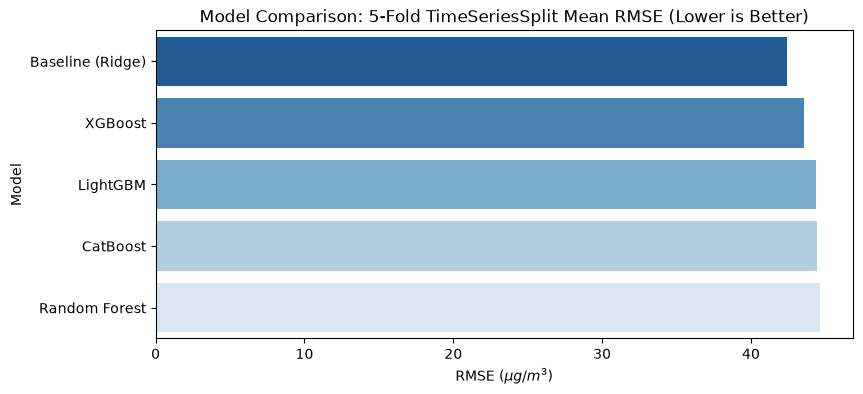

In [2]:
plt.figure(figsize=(9, 4))
sns.barplot(
    data=leaderboard,
    x="Mean RMSE",
    y="Model",
    hue="Model",
    legend=False,
    palette="Blues_r",
)
plt.title("Model Comparison: 5-Fold TimeSeriesSplit Mean RMSE (Lower is Better)")
plt.xlabel("RMSE ($\mu g/m^3$)")
plt.show()

In [3]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit

drop_cols = [
    "City",
    "Date",
    "AQI",
    "AQI_Bucket",
    "Target_PM25_t1",
    "Target_NO2_t1",
]
features = [c for c in df.columns if c not in drop_cols]
X, y = df[features].values, df["Target_PM25_t1"].values

# Fit best model on latest split
tscv = TimeSeriesSplit(n_splits=5)
for train_idx, val_idx in tscv.split(X):
    pass

model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.04,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)
model.fit(X[train_idx], y[train_idx])

# Run SHAP inline
run_shap_analysis(
    model,
    X[train_idx],
    X[val_idx],
    feature_names=features,
    output_dir="../figures",
)

Saved SHAP summary to: ../figures\shap_summary.png
